In [1]:
import pandas as pd
import networkx as nx
import numpy as np
from collections import defaultdict
import time, json, os, re
import scipy.sparse as sp
import gurobipy as gp
from gurobipy import GRB
import json
import geopandas as gpd
from funciones_mapas_graficos import graficar_desde_asignaciones_csv, graficar_eeuu_desde_asignaciones_csv

Total polígonos: 796
Asignados: 796
No asignados: 0


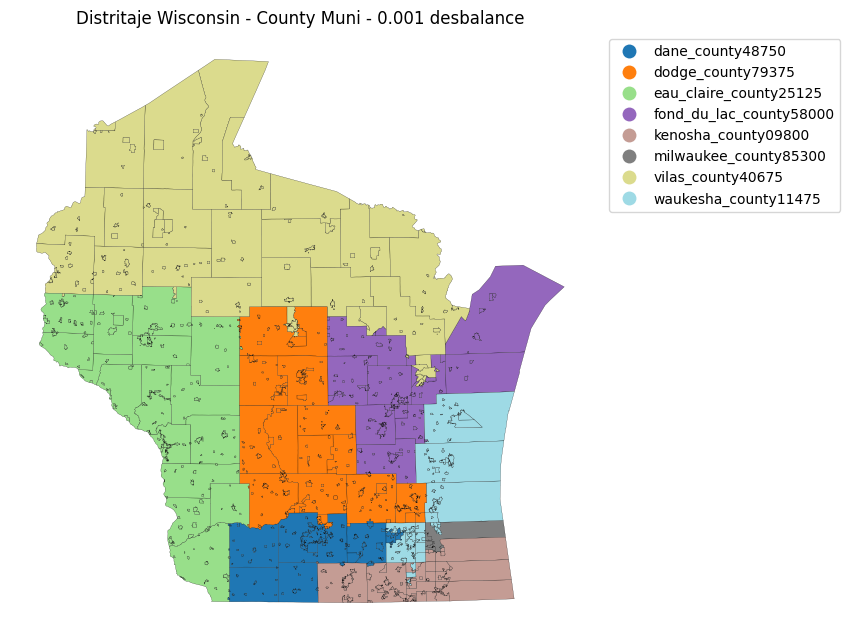

,county_muni_id,county_muni,state,county,muni,pop,pop_hisp,pop_white,pop_black,pop_aian,...,arv_20,adv_20,nrv,ndv,area_land,area_water,node_idx,geometry,comuna,centro
0,Adams County00275,Adams County00275,WI,Adams County,00275,1761.0,75.0,1591.0,14.0,6.0,...,457.8,321.9,357.4,320.6,7.626484e+06,5361.0,0,"POLYGON ((616255.173 12442.083, 615057.896 124...",adams_county00275,dodge_county79375
1,Adams County,Adams County,WI,Adams County,,15538.0,622.0,13671.0,540.0,150.0,...,5534.7,3132.0,4147.2,2925.0,1.605153e+09,87642140.0,1,"POLYGON ((612791.172 -10728.98, 612615.458 -83...",adams_county,dodge_county79375
2,Adams County27950,Adams County27950,WI,Adams County,27950,648.0,23.0,585.0,11.0,1.0,...,170.4,111.2,136.6,115.5,2.331113e+06,114293.0,2,"POLYGON ((615424.615 14850.243, 614618.606 148...",adams_county27950,dodge_county79375
3,Adams County19600,Adams County19600,WI,Adams County,19600,940.0,14.0,888.0,1.0,3.0,...,352.2,248.2,271.5,231.3,2.961059e+07,17433201.0,3,"POLYGON ((602993.223 14773.007, 604207.092 147...",adams_county19600,dodge_county79375
4,Adams County41160,Adams County41160,WI,Adams County,41160,1104.0,15.0,1067.0,1.0,3.0,...,514.0,313.0,418.3,293.0,1.868517e+07,2019933.0,4,"POLYGON ((615816.492 41008.632, 616402.878 411...",adams_county41160,dodge_county79375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
791,Wood County63100,Wood County63100,WI,Wood County,63100,813.0,15.0,778.0,0.0,6.0,...,305.0,137.0,244.4,132.4,5.154736e+06,26373.0,791,"POLYGON ((590476.373 65676.607, 588907.988 656...",wood_county63100,dodge_county79375
792,Wood County64175,Wood County64175,WI,Wood County,64175,1762.0,41.0,1585.0,16.0,13.0,...,574.0,442.5,490.4,405.3,1.355627e+07,3228745.0,792,"MULTIPOLYGON (((616701.295 56377.84, 616716.52...",wood_county64175,dodge_county79375
793,Wood County70000,Wood County70000,WI,Wood County,70000,433.0,20.0,410.0,0.0,2.0,...,164.0,103.0,124.1,104.1,3.118688e+06,0.0,793,"POLYGON ((616698.313 73662.307, 616713.513 732...",wood_county70000,dodge_county79375
794,Wood County82650,Wood County82650,WI,Wood County,82650,513.0,4.0,484.0,0.0,0.0,...,204.6,95.8,169.6,91.1,2.990849e+06,0.0,794,"POLYGON ((602841.427 72869.078, 603111.314 728...",wood_county82650,dodge_county79375


In [6]:
graficar_eeuu_desde_asignaciones_csv(
    "resultados_eeuu_county_muni/wi_sys/t_055/t_055_asignaciones.csv",
    "DataEEUU2/wi_paper_county_muni/nodes.geojson",
    "MAPAS_EEUU_GRAFICOS/mapa_wisconsin_county_muni_t055.png",
    titulo="Distritaje Wisconsin - County Muni - 0.001 desbalance",
    col_geo="county_muni"
)

Total polígonos: 796
Asignados: 796
No asignados: 0


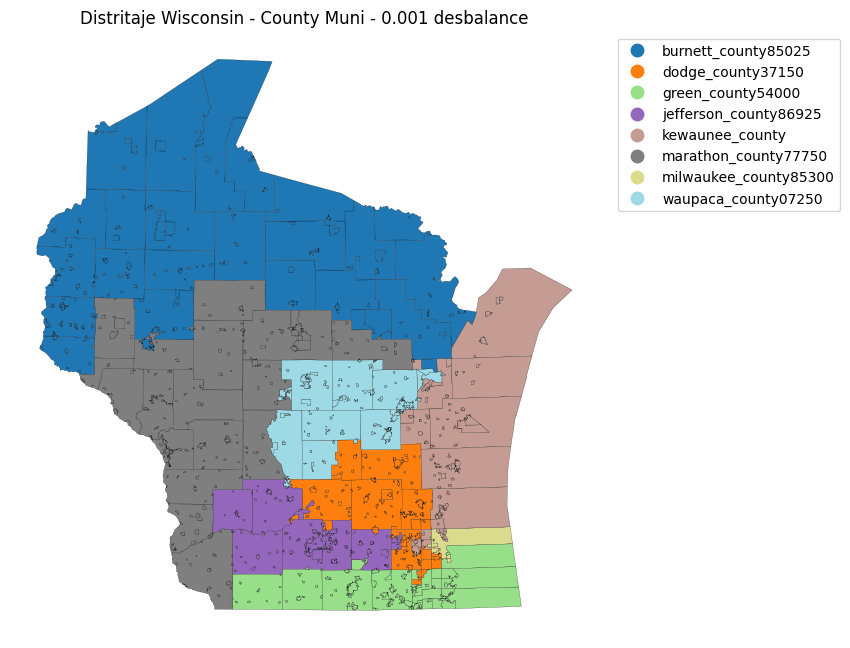

,county_muni_id,county_muni,state,county,muni,pop,pop_hisp,pop_white,pop_black,pop_aian,...,arv_20,adv_20,nrv,ndv,area_land,area_water,node_idx,geometry,comuna,centro
0,Adams County00275,Adams County00275,WI,Adams County,00275,1761.0,75.0,1591.0,14.0,6.0,...,457.8,321.9,357.4,320.6,7.626484e+06,5361.0,0,"POLYGON ((616255.173 12442.083, 615057.896 124...",adams_county00275,waupaca_county07250
1,Adams County,Adams County,WI,Adams County,,15538.0,622.0,13671.0,540.0,150.0,...,5534.7,3132.0,4147.2,2925.0,1.605153e+09,87642140.0,1,"POLYGON ((612791.172 -10728.98, 612615.458 -83...",adams_county,waupaca_county07250
2,Adams County27950,Adams County27950,WI,Adams County,27950,648.0,23.0,585.0,11.0,1.0,...,170.4,111.2,136.6,115.5,2.331113e+06,114293.0,2,"POLYGON ((615424.615 14850.243, 614618.606 148...",adams_county27950,waupaca_county07250
3,Adams County19600,Adams County19600,WI,Adams County,19600,940.0,14.0,888.0,1.0,3.0,...,352.2,248.2,271.5,231.3,2.961059e+07,17433201.0,3,"POLYGON ((602993.223 14773.007, 604207.092 147...",adams_county19600,waupaca_county07250
4,Adams County41160,Adams County41160,WI,Adams County,41160,1104.0,15.0,1067.0,1.0,3.0,...,514.0,313.0,418.3,293.0,1.868517e+07,2019933.0,4,"POLYGON ((615816.492 41008.632, 616402.878 411...",adams_county41160,waupaca_county07250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
791,Wood County63100,Wood County63100,WI,Wood County,63100,813.0,15.0,778.0,0.0,6.0,...,305.0,137.0,244.4,132.4,5.154736e+06,26373.0,791,"POLYGON ((590476.373 65676.607, 588907.988 656...",wood_county63100,marathon_county77750
792,Wood County64175,Wood County64175,WI,Wood County,64175,1762.0,41.0,1585.0,16.0,13.0,...,574.0,442.5,490.4,405.3,1.355627e+07,3228745.0,792,"MULTIPOLYGON (((616701.295 56377.84, 616716.52...",wood_county64175,waupaca_county07250
793,Wood County70000,Wood County70000,WI,Wood County,70000,433.0,20.0,410.0,0.0,2.0,...,164.0,103.0,124.1,104.1,3.118688e+06,0.0,793,"POLYGON ((616698.313 73662.307, 616713.513 732...",wood_county70000,marathon_county77750
794,Wood County82650,Wood County82650,WI,Wood County,82650,513.0,4.0,484.0,0.0,0.0,...,204.6,95.8,169.6,91.1,2.990849e+06,0.0,794,"POLYGON ((602841.427 72869.078, 603111.314 728...",wood_county82650,marathon_county77750


In [5]:
graficar_eeuu_desde_asignaciones_csv(
    "resultados_eeuu_county_muni/wi_sys/t_077/t_077_asignaciones.csv",
    "DataEEUU2/wi_paper_county_muni/nodes.geojson",
    "MAPAS_EEUU_GRAFICOS/mapa_wisconsin_county_muni_t077.png",
    titulo="Distritaje Wisconsin - County Muni - 0.001 desbalance",
    col_geo="county_muni"
)

Total polígonos: 796
Asignados: 796
No asignados: 0


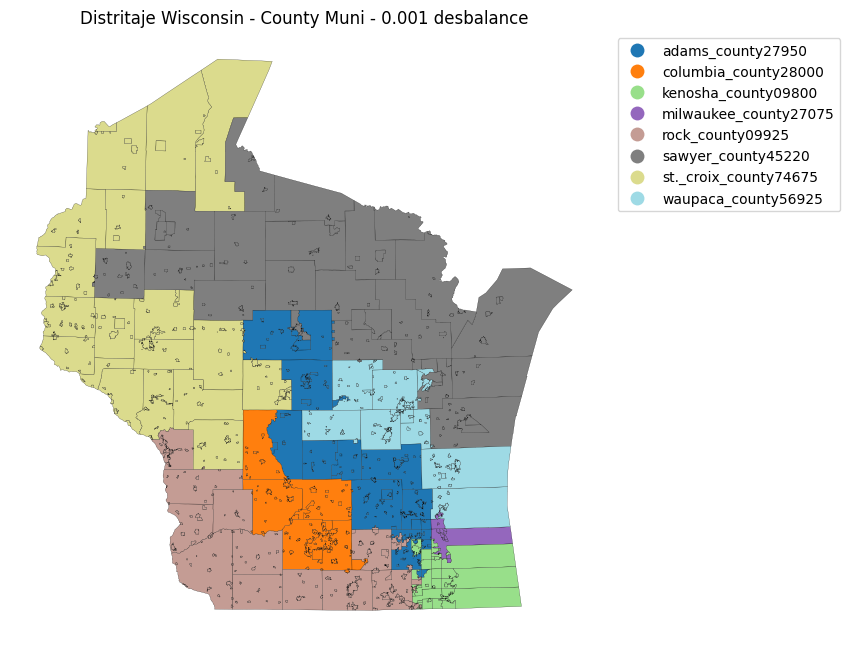

,county_muni_id,county_muni,state,county,muni,pop,pop_hisp,pop_white,pop_black,pop_aian,...,arv_20,adv_20,nrv,ndv,area_land,area_water,node_idx,geometry,comuna,centro
0,Adams County00275,Adams County00275,WI,Adams County,00275,1761.0,75.0,1591.0,14.0,6.0,...,457.8,321.9,357.4,320.6,7.626484e+06,5361.0,0,"POLYGON ((616255.173 12442.083, 615057.896 124...",adams_county00275,adams_county27950
1,Adams County,Adams County,WI,Adams County,,15538.0,622.0,13671.0,540.0,150.0,...,5534.7,3132.0,4147.2,2925.0,1.605153e+09,87642140.0,1,"POLYGON ((612791.172 -10728.98, 612615.458 -83...",adams_county,adams_county27950
2,Adams County27950,Adams County27950,WI,Adams County,27950,648.0,23.0,585.0,11.0,1.0,...,170.4,111.2,136.6,115.5,2.331113e+06,114293.0,2,"POLYGON ((615424.615 14850.243, 614618.606 148...",adams_county27950,adams_county27950
3,Adams County19600,Adams County19600,WI,Adams County,19600,940.0,14.0,888.0,1.0,3.0,...,352.2,248.2,271.5,231.3,2.961059e+07,17433201.0,3,"POLYGON ((602993.223 14773.007, 604207.092 147...",adams_county19600,adams_county27950
4,Adams County41160,Adams County41160,WI,Adams County,41160,1104.0,15.0,1067.0,1.0,3.0,...,514.0,313.0,418.3,293.0,1.868517e+07,2019933.0,4,"POLYGON ((615816.492 41008.632, 616402.878 411...",adams_county41160,adams_county27950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
791,Wood County63100,Wood County63100,WI,Wood County,63100,813.0,15.0,778.0,0.0,6.0,...,305.0,137.0,244.4,132.4,5.154736e+06,26373.0,791,"POLYGON ((590476.373 65676.607, 588907.988 656...",wood_county63100,st._croix_county74675
792,Wood County64175,Wood County64175,WI,Wood County,64175,1762.0,41.0,1585.0,16.0,13.0,...,574.0,442.5,490.4,405.3,1.355627e+07,3228745.0,792,"MULTIPOLYGON (((616701.295 56377.84, 616716.52...",wood_county64175,st._croix_county74675
793,Wood County70000,Wood County70000,WI,Wood County,70000,433.0,20.0,410.0,0.0,2.0,...,164.0,103.0,124.1,104.1,3.118688e+06,0.0,793,"POLYGON ((616698.313 73662.307, 616713.513 732...",wood_county70000,st._croix_county74675
794,Wood County82650,Wood County82650,WI,Wood County,82650,513.0,4.0,484.0,0.0,0.0,...,204.6,95.8,169.6,91.1,2.990849e+06,0.0,794,"POLYGON ((602841.427 72869.078, 603111.314 728...",wood_county82650,st._croix_county74675


In [4]:
graficar_eeuu_desde_asignaciones_csv(
    "resultados_eeuu_county_muni/wi_sys/t_034/t_034_asignaciones.csv",
    "DataEEUU2/wi_paper_county_muni/nodes.geojson",
    "MAPAS_EEUU_GRAFICOS/mapa_wisconsin_county_muni_t034.png",
    titulo="Distritaje Wisconsin - County Muni - 0.001 desbalance",
    col_geo="county_muni"
)

Total polígonos: 345
Asignados: 345
No asignados: 0


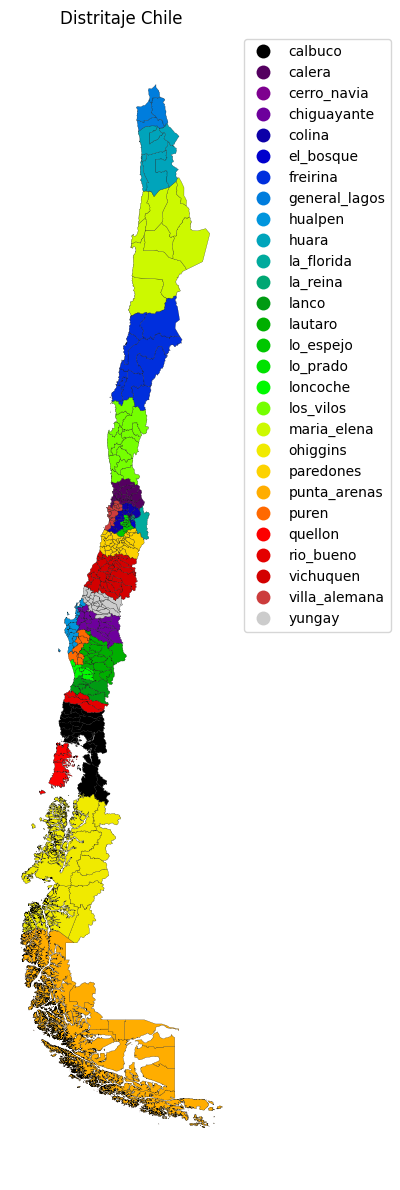

In [12]:
gdf_mapa = graficar_desde_asignaciones_csv(
    ruta_asignaciones="resultados/resultados_CL_SYS_epsilon_0.87/t_023/t_023_asignaciones.csv",
    ruta_geojson="DataChile2/chile_paper/nodes.gpkg",
    output_png="MAPAS_CHILE_GRAFICOS/mapa_chile_t023.png",
    titulo="Distritaje Chile",
    clip_continental=True,
    legend=True
)